In [28]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement strict depuis Supabase en respectant la structure DB fournie
from src.db import fetch_all

tables = {
    'run': 'Run',
    'stage': 'Stage',
    'room': 'Room',
    'playerstate': 'PlayerState',
    'inventory': 'Inventory',
    'passive_item': 'PassiveItem',
    'active_item': 'ActiveItem',
    'playerstate_active': 'PlayerStateActive'
}

dfs = {}
for key, tbl in tables.items():
    try:
        tmp = fetch_all(tbl)
        if tmp is None:
            tmp = pd.DataFrame()
        dfs[key] = tmp
        print(f"Fetched table {tbl} -> shape {tmp.shape}")
    except Exception as e:
        print(f"Warning: could not fetch table {tbl}: {e}")
        dfs[key] = pd.DataFrame()

# Ensure we have at least Run and PlayerState
if dfs['run'].empty or dfs['playerstate'].empty:
    raise RuntimeError('Les tables `Run` et `PlayerState` sont requises dans Supabase.')

# 1) Final player state per run (dernier Frame)
ps = dfs['playerstate']
ps = ps.sort_values(['id_run', 'Frame']).groupby('id_run', as_index=False).last()

player_features = ps[['id_run',
                      'Damage','FireDelay','ShotSpeed','TearRange','MoveSpeed','Luck',
                      'Hearts','MaxHearts','SoulHearts','BlackHearts','BoneHearts',
                      'Coins','Bombs','Keys','DamageTaken']].copy()

# 2) Stage-level aggregates per run (StageVariant, Curses)
st = dfs['stage']
if not st.empty:
    stage_agg = st.groupby('id_run', as_index=False).agg({
        'StageVariant': 'max',
        'Curses': 'sum'
    })
else:
    stage_agg = pd.DataFrame(columns=['id_run','StageVariant','Curses'])

# 3) Room-level aggregates per run (ClearDurationFrames, RoomType mode)
r = dfs['room']
if not r.empty:
    def mode_or_nan(x):
        m = x.mode()
        return m.iat[0] if (not m.empty) else np.nan
    room_agg = r.groupby('id_run', as_index=False).agg({
        'ClearDurationFrames': 'mean',
        'RoomType': mode_or_nan
    })
else:
    room_agg = pd.DataFrame(columns=['id_run','ClearDurationFrames','RoomType'])

# 4) Inventory counts and passive quality per run
inv = dfs['inventory']
passive = dfs['passive_item']
if not inv.empty:
    # map inventory rows to id_run via playerstate id
    ps_id_map = ps[['id', 'id_run']].rename(columns={'id':'id_playerstate'})
    inv2 = inv.merge(ps_id_map, on='id_playerstate', how='left')
    inv_cnt = inv2.groupby('id_run', as_index=False)['Count'].sum().rename(columns={'Count':'Inventory_Count'})
    # passive quality (avg) join
    if not passive.empty:
        inv_pass = inv2.merge(passive[['id','Quality']], left_on='id_passiveitem', right_on='id', how='left')
        inv_pass['Quality'] = pd.to_numeric(inv_pass['Quality'], errors='coerce')
        passive_quality = inv_pass.groupby('id_run', as_index=False)['Quality'].mean().rename(columns={'Quality':'Passive_Avg_Quality'})
    else:
        passive_quality = pd.DataFrame(columns=['id_run','Passive_Avg_Quality'])
else:
    inv_cnt = pd.DataFrame(columns=['id_run','Inventory_Count'])
    passive_quality = pd.DataFrame(columns=['id_run','Passive_Avg_Quality'])

# 5) Active item quality per run via PlayerStateActive
ps_active = dfs['playerstate_active']
active = dfs['active_item']
if not ps_active.empty:
    ps_act2 = ps_active.merge(ps[['id','id_run']], left_on='id_playerstate', right_on='id', how='left')
    if not active.empty:
        ps_act2 = ps_act2.merge(active[['id','Quality']], left_on='id_activeitem', right_on='id', how='left')
        ps_act2['Quality'] = pd.to_numeric(ps_act2['Quality'], errors='coerce')
        active_quality = ps_act2.groupby('id_run', as_index=False)['Quality'].mean().rename(columns={'Quality':'Active_Avg_Quality'})
    else:
        active_quality = pd.DataFrame(columns=['id_run','Active_Avg_Quality'])
else:
    active_quality = pd.DataFrame(columns=['id_run','Active_Avg_Quality'])

# 6) Run-level target and metadata
runs = dfs['run']
if 'id' in runs.columns and 'Duration' in runs.columns:
    run_meta = runs[['id','Duration','Victory']].rename(columns={'id':'id_run'})
else:
    # fallback: try other numeric target columns
    possible = [c for c in runs.columns if c.lower() in ('duration','endframe','end_frame')]
    if possible:
        run_meta = runs[['id', possible[0]]].rename(columns={'id':'id_run', possible[0]:'Duration'})
    else:
        raise RuntimeError('La table `Run` doit contenir une colonne `Duration` ou équivalente.')

# 7) Merge all features
dfs_to_merge = [player_features, stage_agg, room_agg, inv_cnt, passive_quality, active_quality, run_meta]
from functools import reduce
run_df = reduce(lambda left, right: pd.merge(left, right, on='id_run', how='left'), dfs_to_merge)

# Préparer le DataFrame final pour corrélation
# Respecter strictement les noms de colonnes de la DB fournis
analysis_cols = [
    'StageVariant','Curses','ClearDurationFrames',
    'Damage','FireDelay','ShotSpeed','TearRange','MoveSpeed','Luck',
    'Hearts','MaxHearts','SoulHearts','BlackHearts','BoneHearts',
    'Coins','Bombs','Keys','DamageTaken',
    'Inventory_Count','Passive_Avg_Quality','Active_Avg_Quality',
    'Duration'
]

# Garder seulement les colonnes présentes
analysis_cols_present = [c for c in analysis_cols if c in run_df.columns]
print('Colonnes d\'analyse retenues:', analysis_cols_present)

df_numeric = run_df[analysis_cols_present].copy()
for c in df_numeric.columns:
    df_numeric[c] = pd.to_numeric(df_numeric[c], errors='coerce')

print('NA par colonne:')
print(df_numeric.isna().sum())

# Imputer par la médiane pour les features, garder Duration non nulle
if 'Duration' in df_numeric.columns:
    df_numeric = df_numeric.dropna(subset=['Duration'])
for c in df_numeric.columns:
    if c != 'Duration' and df_numeric[c].isna().any():
        df_numeric[c].fillna(df_numeric[c].median(), inplace=True)

# Matrice de corrélation
corr = df_numeric.corr(method='pearson')

# Sauvegarde intermédiaire
os.makedirs('notebooks/outputs', exist_ok=True)
df_numeric.to_csv('notebooks/outputs/run_level_features.csv', index=False)


Fetched table Run -> shape (32, 11)
Fetched table Stage -> shape (53, 8)
Fetched table Room -> shape (370, 11)
Fetched table PlayerState -> shape (801, 22)
Fetched table Inventory -> shape (2944, 4)
Fetched table PassiveItem -> shape (556, 4)
Fetched table ActiveItem -> shape (170, 4)
Fetched table PlayerStateActive -> shape (467, 5)
Colonnes d'analyse retenues: ['StageVariant', 'Curses', 'ClearDurationFrames', 'Damage', 'FireDelay', 'ShotSpeed', 'TearRange', 'MoveSpeed', 'Luck', 'Hearts', 'MaxHearts', 'SoulHearts', 'BlackHearts', 'BoneHearts', 'Coins', 'Bombs', 'Keys', 'DamageTaken', 'Inventory_Count', 'Passive_Avg_Quality', 'Active_Avg_Quality', 'Duration']
NA par colonne:
StageVariant            0
Curses                  0
ClearDurationFrames     2
Damage                  0
FireDelay               0
ShotSpeed               0
TearRange               0
MoveSpeed               0
Luck                    0
Hearts                  0
MaxHearts               0
SoulHearts              0
Blac

C:\Users\TCYH5041\AppData\Local\Temp\1\ipykernel_11484\968004653.py:146: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_numeric[c].fillna(df_numeric[c].median(), inplace=True)
C:\Users\TCYH5041\AppData\Local\Temp\1\ipykernel_11484\968004653.py:146: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series thro

**Visualisations et top variables**

Les cellules suivantes affichent les graphiques (heatmap, clustermap, barplot) directement dans le notebook et impriment les variables les plus corrélées avec `Duration`.

Top 10 variables positivement corrélées avec Duration:


SoulHearts            0.811542
Bombs                 0.716822
StageVariant          0.694194
MoveSpeed             0.685828
Keys                  0.674538
Inventory_Count       0.629331
Active_Avg_Quality    0.482239
Luck                  0.463623
Coins                 0.455950
TearRange             0.369836
Name: Duration, dtype: float64


Top 10 variables négativement corrélées avec Duration:


Passive_Avg_Quality    0.209079
Damage                 0.191138
DamageTaken            0.062254
BlackHearts            0.000000
BoneHearts             0.000000
Curses                -0.033518
ClearDurationFrames   -0.083900
Hearts                -0.271577
MaxHearts             -0.438893
FireDelay             -0.763929
Name: Duration, dtype: float64

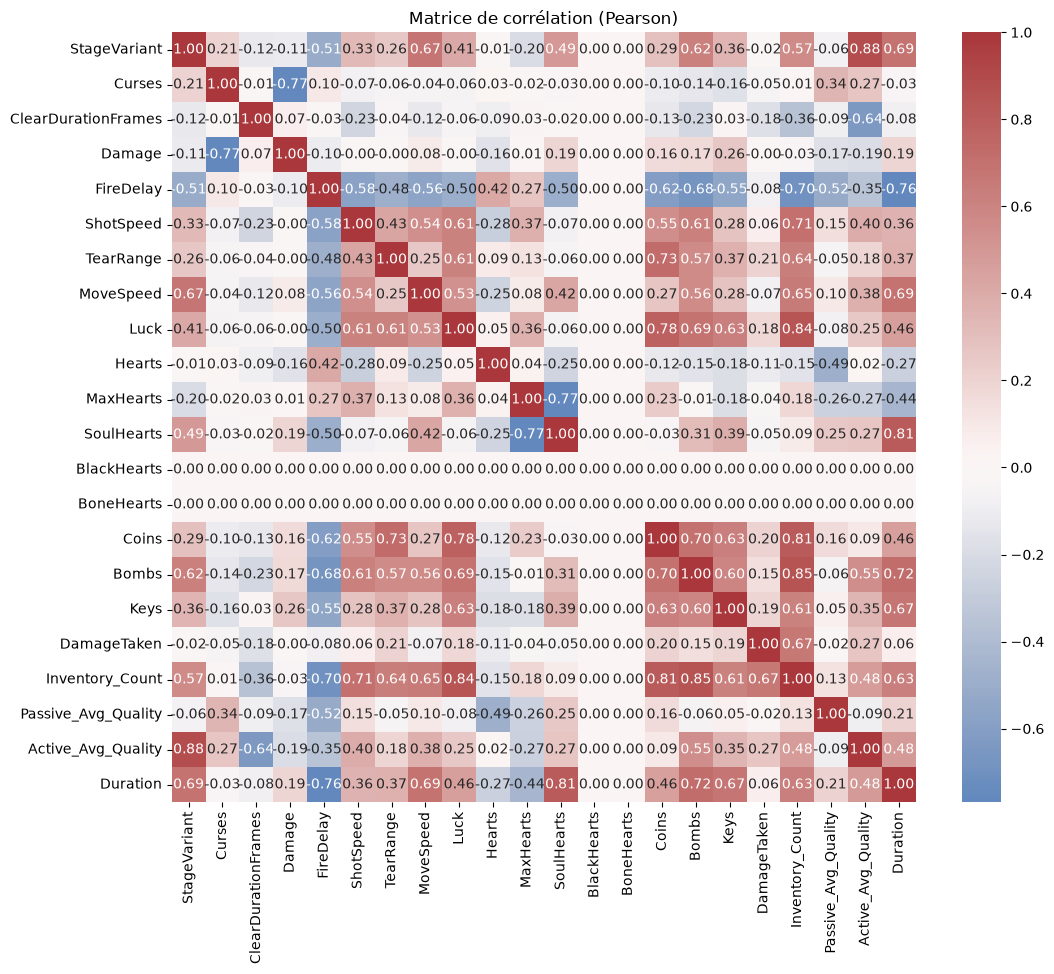

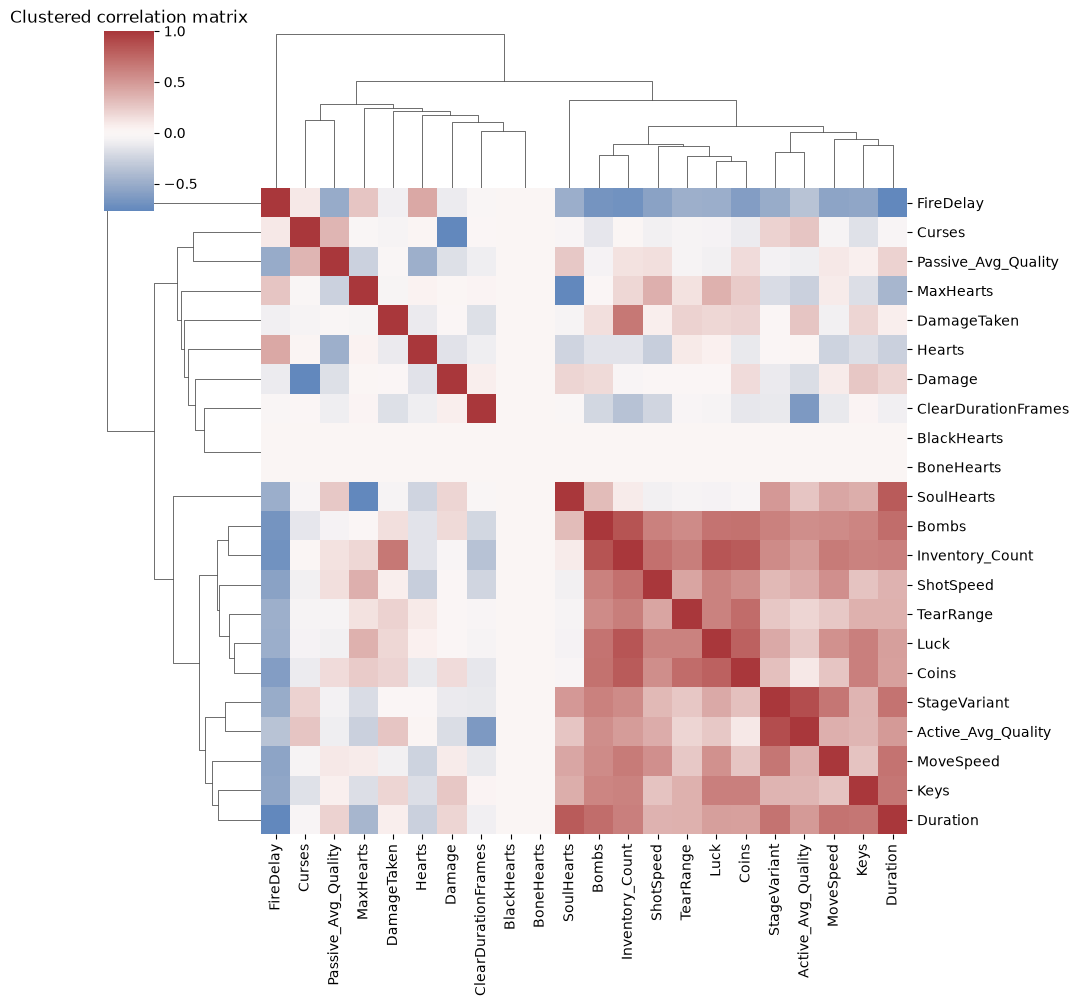

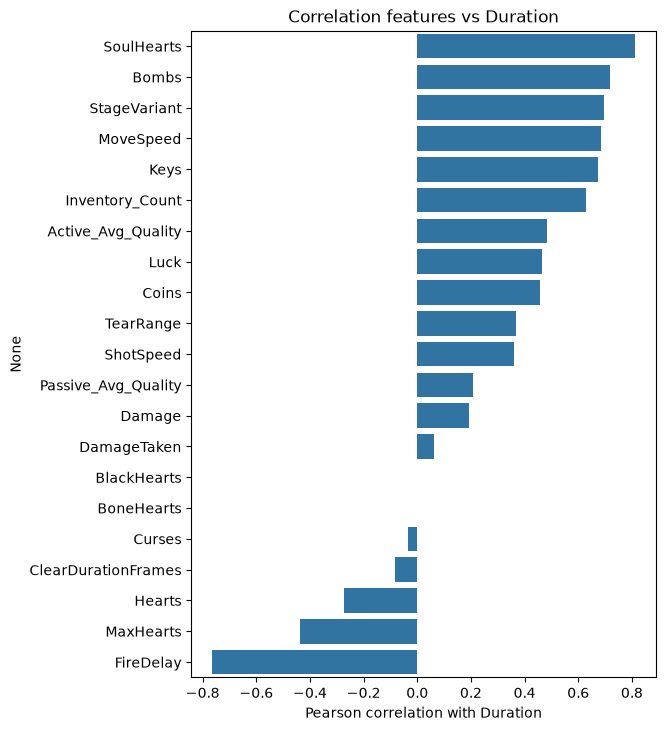

Pairplot failed: Data must be 1-dimensional, got ndarray of shape (32, 2) instead


In [29]:
# Afficher les graphes inline et lister les top variables

%matplotlib inline

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

out_dir = 'notebooks/outputs'
csv_path = os.path.join(out_dir, 'run_level_features.csv')
if not os.path.exists(csv_path):
    raise RuntimeError('run_level_features.csv non trouvé — exécutez la cellule de prétraitement.')

df_numeric = pd.read_csv(csv_path)
# Recalculer la matrice de corrélation proprement
corr = df_numeric.corr(method='pearson')
corr = corr.replace([np.inf, -np.inf], np.nan).fillna(0)

# Afficher top variables corrélées avec Duration
if 'Duration' in corr.columns:
    corr_target = corr['Duration'].drop('Duration').sort_values(ascending=False)
    print('Top 10 variables positivement corrélées avec Duration:')
    display(corr_target.head(10))
    print('\nTop 10 variables négativement corrélées avec Duration:')
    display(corr_target.tail(10))
else:
    print('La colonne `Duration` n\'est pas présente dans la matrice de corrélation.')

# Heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Matrice de corrélation (Pearson)')
plt.show()

# Clustermap (essayer, mais peut échouer si valeurs non finies)
try:
    annot = True if corr.shape[0] <= 20 else False
    g = sns.clustermap(corr, cmap='vlag', center=0, annot=annot, fmt='.2f', figsize=(10,10))
    plt.title('Clustered correlation matrix')
    plt.show()
except Exception as e:
    print('Clustermap failed:', e)

# Barplot correlations avec Duration
if 'Duration' in corr.columns:
    plt.figure(figsize=(6, max(4, len(corr_target)*0.4)))
    sns.barplot(x=corr_target.values, y=corr_target.index)
    plt.xlabel('Pearson correlation with Duration')
    plt.title('Correlation features vs Duration')
    plt.show()

# Pairplot des top variables (top 6 absolues)
if 'Duration' in corr.columns:
    top_vars = corr['Duration'].abs().sort_values(ascending=False).head(6).index.tolist()
    if len(top_vars) > 1:
        try:
            sns.pairplot(df_numeric[top_vars + ['Duration']].dropna(), diag_kind='kde', plot_kws={'alpha':0.6})
            plt.show()
        except Exception as e:
            print('Pairplot failed:', e)
